# GSE44076: First Exploratory Group Comparison

This notebook makes a first probe-level comparison between tumor and paired normal mucosa samples. It calculates group means, a difference on the supplied log2-like scale, Welch two-sample t-tests, and Benjamini-Hochberg adjusted p-values.

The study includes matched tumor and normal samples, but this first pass intentionally ignores that pairing. Results are exploratory rankings, not a definitive differential-expression analysis, biological interpretation, or biomarker list.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis import rank_group_comparison  # noqa: E402
from src.geo_loader import (  # noqa: E402
    align_expression_with_metadata,
    build_sample_metadata_table,
    convert_expression_to_numeric,
    load_geo_expression_table,
    read_geo_series_lines,
)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "GSE44076_series_matrix.txt.gz"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "sample_metadata.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "tumor_vs_paired_normal_probe_ranking.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GROUP_MAP = {
    "Healthy colon mucosa cells": "healthy_mucosa",
    "Normal distant colon mucosa cells": "paired_normal_mucosa",
    "Primary colon adenocarcinoma cells": "tumor",
}

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Load and Align Data

The local expression matrix is aligned to sample metadata and converted to numeric values. The observed scale appears log2-like, so the difference between group means is reported as `log2_fold_change`; that interpretation remains conditional on confirmation of the original preprocessing.

In [2]:
if not RAW_PATH.is_file():
    raise FileNotFoundError(
        "GSE44076 series matrix not found. Place the downloaded file at "
        f"{RAW_PATH}"
    )

expression = load_geo_expression_table(RAW_PATH)
if METADATA_PATH.is_file():
    sample_metadata = pd.read_csv(METADATA_PATH)
else:
    sample_metadata = build_sample_metadata_table(read_geo_series_lines(RAW_PATH))

if "group" not in sample_metadata:
    sample_metadata["group"] = sample_metadata["source_name"].map(GROUP_MAP)
if sample_metadata["group"].isna().any():
    raise ValueError("Some sample source names do not have a documented group label.")

expression, sample_metadata = align_expression_with_metadata(expression, sample_metadata)
expression = convert_expression_to_numeric(expression)

print(f"Aligned expression table: {expression.shape}")
print(f"Missing numeric values: {int(expression.drop(columns='ID_REF').isna().sum().sum()):,}")

Aligned expression table: (49386, 247)
Missing numeric values: 0


## Define the Exploratory Comparison

Only tumor and paired normal mucosa samples are retained. The shorter `paired_normal` label is used in output column names. Individual identifiers are available, but they are not used by this Welch test.

In [3]:
comparison_metadata = sample_metadata[
    sample_metadata["group"].isin(["tumor", "paired_normal_mucosa"])
].copy()
comparison_metadata["comparison_group"] = comparison_metadata["group"].replace(
    {"paired_normal_mucosa": "paired_normal"}
)

group_counts = comparison_metadata["comparison_group"].value_counts()
display(group_counts.rename("sample_count").to_frame())
print("Pairing is ignored in this first-pass test; all 196 samples are treated as independent.")

,sample_count
comparison_group,
paired_normal,98
tumor,98


Pairing is ignored in this first-pass test; all 196 samples are treated as independent.


## Probe-Level Welch Tests and FDR Adjustment

For each probe, the calculation uses tumor mean minus paired-normal mean. Welch's test allows unequal group variances, while Benjamini-Hochberg adjustment controls the expected false discovery rate under its assumptions.

In [4]:
ranking = rank_group_comparison(
    expression,
    comparison_metadata,
    group_column="comparison_group",
    group_a="tumor",
    group_b="paired_normal",
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
ranking.to_csv(OUTPUT_PATH, index=False)

print(f"Probes compared: {len(ranking):,}")
print(f"Saved local ranking: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")
display(ranking.head(10))

Probes compared: 49,386
Saved local ranking: data\processed\tumor_vs_paired_normal_probe_ranking.csv


,probe_id,mean_tumor,mean_paired_normal,log2_fold_change,p_value,adjusted_p_value
0,11728232_a_at,8.911113,3.990905,4.920208,2.535048e-86,1.251959e-81
1,11732838_at,3.747131,10.294447,-6.547316,3.451660e-85,8.523185e-81
2,11715637_a_at,10.478915,12.090254,-1.611339,5.303153e-84,8.730051e-80
3,11724538_a_at,3.355973,8.865290,-5.509316,1.428358e-82,1.763522e-78
4,11726764_at,3.807132,10.423790,-6.616658,2.380832e-79,2.351596e-75
5,11721557_a_at,3.780091,8.060342,-4.280251,2.861874e-79,2.355609e-75
6,11733581_a_at,2.814294,7.465294,-4.651000,6.770358e-76,4.179511e-72
7,11721993_at,8.194611,4.890877,3.303735,6.576536e-76,4.179511e-72
8,11746142_a_at,3.095255,6.206259,-3.111004,3.411538e-75,1.872024e-71
9,11730386_at,3.031321,5.846502,-2.815181,5.599818e-75,2.765526e-71


## Ranking Summary

Low adjusted p-values are frequent in this simple comparison. Their count should be interpreted cautiously because the test ignores within-individual pairing and does not model other covariates.

In [5]:
fdr_counts = pd.Series(
    {
        "adjusted_p_value < 0.05": int((ranking["adjusted_p_value"] < 0.05).sum()),
        "adjusted_p_value < 0.01": int((ranking["adjusted_p_value"] < 0.01).sum()),
        "adjusted_p_value < 0.001": int((ranking["adjusted_p_value"] < 0.001).sum()),
    },
    name="probe_count",
)
display(fdr_counts.to_frame())

top_absolute_change = (
    ranking.assign(absolute_log2_fold_change=ranking["log2_fold_change"].abs())
    .sort_values(["absolute_log2_fold_change", "adjusted_p_value"], ascending=[False, True])
    .head(10)
)
display(top_absolute_change)

,probe_count
adjusted_p_value < 0.05,32964
adjusted_p_value < 0.01,29156
adjusted_p_value < 0.001,25320


,probe_id,mean_tumor,mean_paired_normal,log2_fold_change,p_value,adjusted_p_value,absolute_log2_fold_change
170,11729583_x_at,4.582909,12.300246,-7.717337,4.129349e-58,1.187177e-55,7.717337
953,11728771_a_at,4.890284,12.159907,-7.269623,6.067454e-44,3.140957e-42,7.269623
101,11729582_s_at,3.803621,10.780727,-6.977105,1.453862e-60,6.955382e-58,6.977105
21,11737294_a_at,3.137554,10.066269,-6.928715,1.972678e-71,4.428304e-68,6.928715
4,11726764_at,3.807132,10.423790,-6.616658,2.380832e-79,2.351596e-75,6.616658
477,11733744_at,5.079228,11.686735,-6.607507,5.580958e-50,5.766134e-48,6.607507
1,11732838_at,3.747131,10.294447,-6.547316,3.451660e-85,8.523185e-81,6.547316
1508,11722059_at,6.235244,12.613878,-6.378634,3.726607e-39,1.219630e-37,6.378634
427,11730973_a_at,4.607981,10.819588,-6.211607,4.834760e-51,5.578726e-49,6.211607
258,11731957_at,6.299352,12.347068,-6.047716,4.805810e-55,9.163695e-53,6.047716


## Exploratory Volcano Plot

Color highlights probes with adjusted p-value below 0.05 and absolute mean difference of at least 1 on the supplied scale. These visual thresholds organize the plot; they do not define biomarkers or clinical relevance.

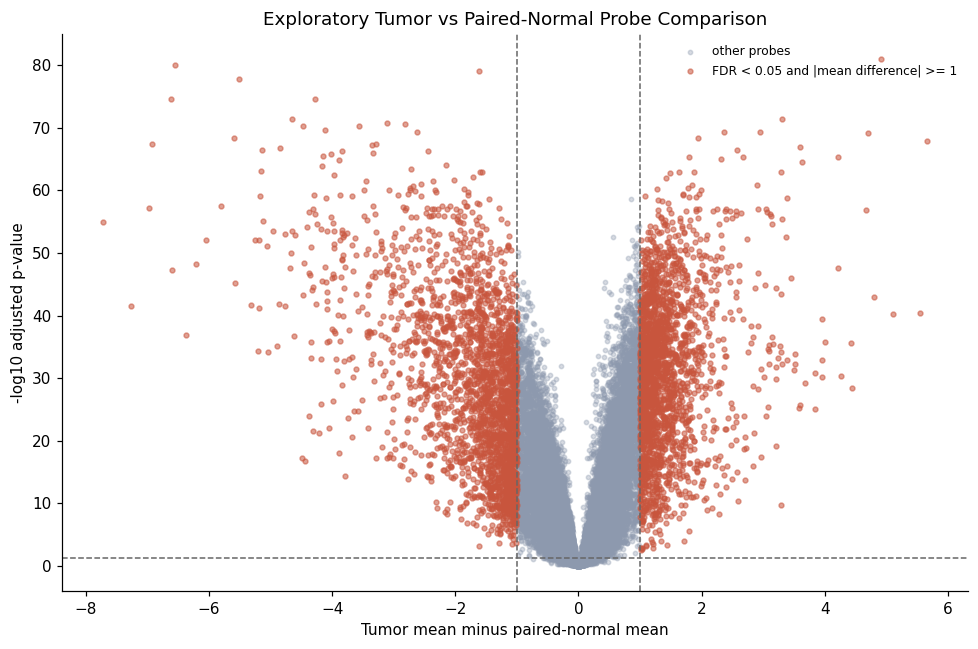

In [6]:
plot_table = ranking.copy()
plot_table["minus_log10_adjusted_p"] = -np.log10(
    plot_table["adjusted_p_value"].clip(lower=np.finfo(float).tiny)
)
plot_table["highlight"] = (
    (plot_table["adjusted_p_value"] < 0.05)
    & (plot_table["log2_fold_change"].abs() >= 1)
)

fig, ax = plt.subplots(figsize=(9, 6))
background = plot_table[~plot_table["highlight"]]
highlighted = plot_table[plot_table["highlight"]]
ax.scatter(
    background["log2_fold_change"],
    background["minus_log10_adjusted_p"],
    s=8,
    alpha=0.35,
    color="#8D99AE",
    label="other probes",
)
ax.scatter(
    highlighted["log2_fold_change"],
    highlighted["minus_log10_adjusted_p"],
    s=10,
    alpha=0.55,
    color="#C8553D",
    label="FDR < 0.05 and |mean difference| >= 1",
)
ax.axvline(-1, color="#666666", linestyle="--", linewidth=1)
ax.axvline(1, color="#666666", linestyle="--", linewidth=1)
ax.axhline(-np.log10(0.05), color="#666666", linestyle="--", linewidth=1)
ax.set_title("Exploratory Tumor vs Paired-Normal Probe Comparison")
ax.set_xlabel("Tumor mean minus paired-normal mean")
ax.set_ylabel("-log10 adjusted p-value")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "tumor_vs_paired_normal_volcano.png", dpi=180, bbox_inches="tight")
plt.show()

## Probe-Level Exploratory Heatmap

The heatmap uses 20 top-ranked probes and all comparison samples, ordered by group. Values are centered and scaled within each probe to show relative sample patterns. This is a compact visualization of the ranking, not a biomarker heatmap.

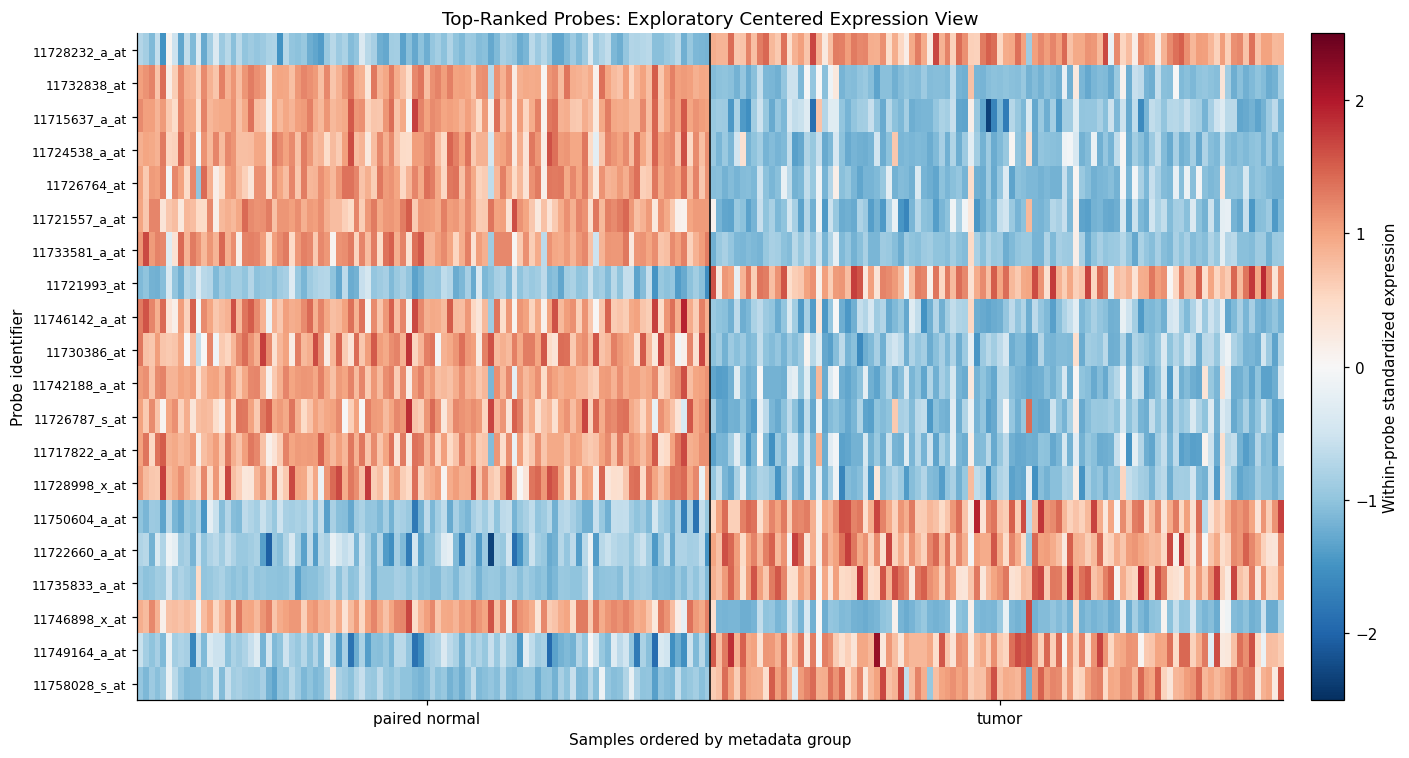

In [7]:
top_probe_ids = ranking.head(20)["probe_id"].tolist()
ordered_metadata = comparison_metadata.sort_values(
    "comparison_group",
    key=lambda values: values.map({"paired_normal": 0, "tumor": 1}),
)
ordered_samples = ordered_metadata["sample_accession"].tolist()
heatmap_values = expression.set_index("ID_REF").loc[top_probe_ids, ordered_samples]
probe_standard_deviation = heatmap_values.std(axis=1).replace(0, np.nan)
heatmap_z = heatmap_values.sub(heatmap_values.mean(axis=1), axis=0).div(
    probe_standard_deviation,
    axis=0,
)
normal_count = int((ordered_metadata["comparison_group"] == "paired_normal").sum())

fig, ax = plt.subplots(figsize=(14, 7))
image = ax.imshow(heatmap_z, aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5)
ax.axvline(normal_count - 0.5, color="#222222", linewidth=1.2)
ax.set_title("Top-Ranked Probes: Exploratory Centered Expression View")
ax.set_xlabel("Samples ordered by metadata group")
ax.set_ylabel("Probe identifier")
ax.set_yticks(range(len(top_probe_ids)), labels=top_probe_ids, fontsize=8)
ax.set_xticks([normal_count / 2, normal_count + (len(ordered_samples) - normal_count) / 2])
ax.set_xticklabels(["paired normal", "tumor"])
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label("Within-probe standardized expression")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "tumor_vs_paired_normal_top_probe_heatmap.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## Limitations and Next Check

- Welch tests treat all samples as independent and therefore ignore the matched tumor-normal design.
- The original transformation and platform annotation still require confirmation.
- Probe identifiers have not been mapped to genes, so no gene-level interpretation is made.
- Low adjusted p-values do not establish effect importance, reproducibility, mechanism, or clinical relevance.
- A more appropriate next analysis would explicitly match samples by individual identifier and compare paired differences while documenting any incomplete pairs.